In [274]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import kagglehub
import os

In [275]:
path = kagglehub.dataset_download('blastchar/telco-customer-churn')
csv_path =  os.path.join(path, 'WA_Fn-UseC_-Telco-Customer-Churn.csv')
df = pd.read_csv(csv_path)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [276]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [277]:
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [278]:
missing_values = df.isnull().sum()
missing_values[missing_values>0]

Series([], dtype: int64)

In [279]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [280]:
missing_values = df.isnull().sum()
print('jumlah missing values saat mengubah kolom TotalCharge menjadi numerik\n',missing_values[missing_values>0].values)
df = df.dropna()
missing_values = df.isnull().sum()
print('jumlah missing values saat mengedrop missing_values\n',missing_values[missing_values>0].values)

jumlah missing values saat mengubah kolom TotalCharge menjadi numerik
 [11]
jumlah missing values saat mengedrop missing_values
 []


In [281]:
df.duplicated().sum()

np.int64(0)

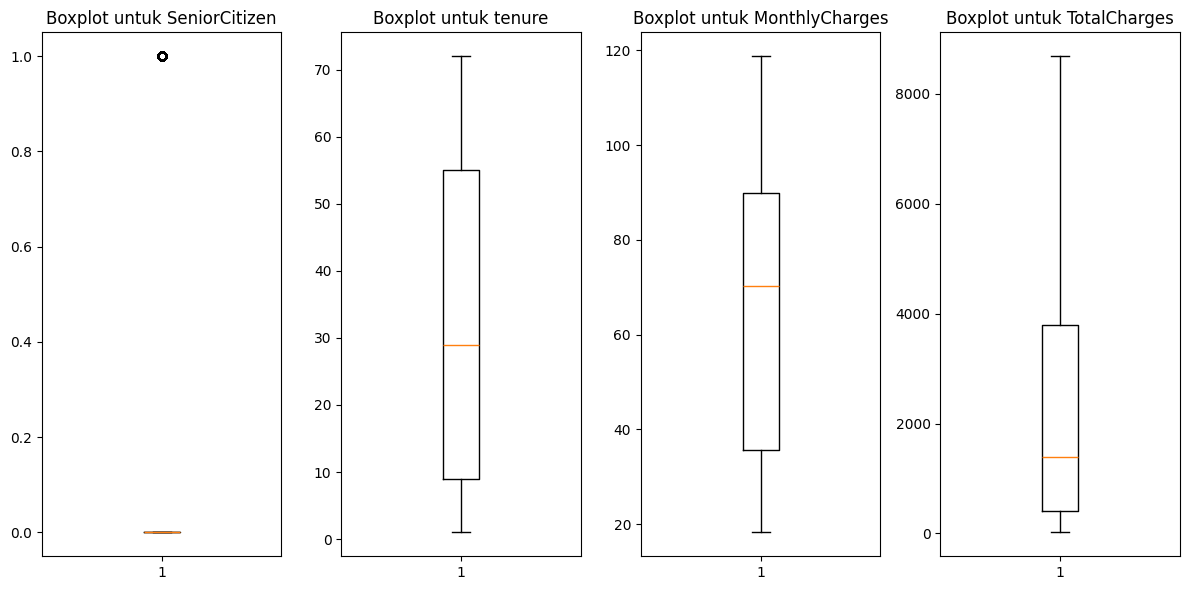

In [282]:
numerik = df.select_dtypes(include=['number']).columns
n_features = len(numerik)
n_col = 4
n_row = -(-n_features//n_col)
plt.figure(figsize=(12,6))
for i, col in enumerate(df[numerik], 1):
    plt.subplot(n_row, n_col, i)
    plt.boxplot(x=df[col])
    plt.title(f'Boxplot untuk {col}')

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Sebaran Churn')

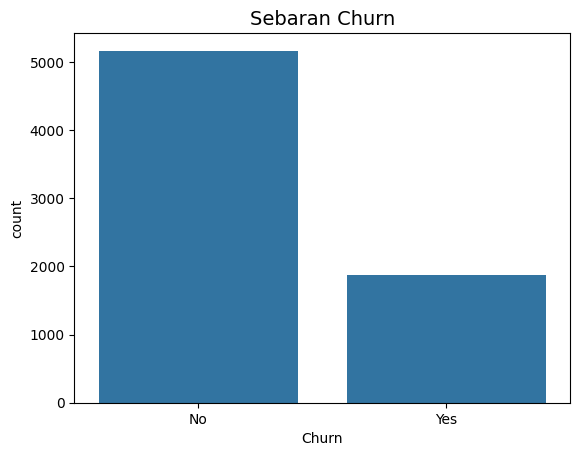

In [283]:
sns.countplot(x='Churn', data=df)
plt.title('Sebaran Churn', fontsize=14)

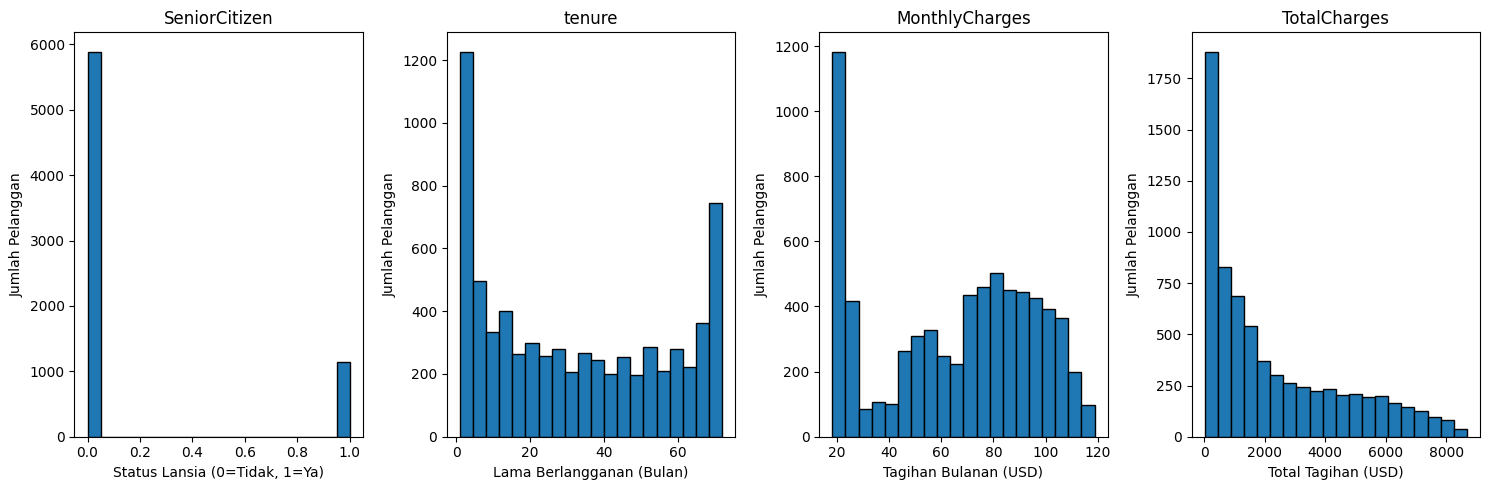

In [284]:
labels = {
    'SeniorCitizen': 'Status Lansia (0=Tidak, 1=Ya)',
    'tenure': 'Lama Berlangganan (Bulan)',
    'MonthlyCharges': 'Tagihan Bulanan (USD)',
    'TotalCharges': 'Total Tagihan (USD)'
}

fig, ax = plt.subplots(1, 4, figsize=(15,5))

for i, col in enumerate(df[numerik]):
    ax[i].hist(df[col], bins=20, edgecolor='black')
    ax[i].set_title(col)
    ax[i].set_ylabel('Jumlah Pelanggan')
    ax[i].set_xlabel(labels[col])
    
plt.tight_layout()
plt.show()

In [285]:
df = df.drop(columns=['customerID'])

In [286]:
categorical = df.select_dtypes(include=['string','object']).columns
for col in categorical:
    print(df[col].value_counts())
    print('-'*10)

gender
Male      3549
Female    3483
Name: count, dtype: int64
----------
Partner
No     3639
Yes    3393
Name: count, dtype: int64
----------
Dependents
No     4933
Yes    2099
Name: count, dtype: int64
----------
PhoneService
Yes    6352
No      680
Name: count, dtype: int64
----------
MultipleLines
No                  3385
Yes                 2967
No phone service     680
Name: count, dtype: int64
----------
InternetService
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: int64
----------
OnlineSecurity
No                     3497
Yes                    2015
No internet service    1520
Name: count, dtype: int64
----------
OnlineBackup
No                     3087
Yes                    2425
No internet service    1520
Name: count, dtype: int64
----------
DeviceProtection
No                     3094
Yes                    2418
No internet service    1520
Name: count, dtype: int64
----------
TechSupport
No                     3472
Yes                    2

In [287]:
binermap = {
    'Yes' : 1,
    'No' : 0
}
binerlist = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
for col in binerlist:
    df[col] = df[col].map(binermap)

df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

kolom_multi = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
df_final = pd.get_dummies(df, columns=kolom_multi, drop_first=True)
df_final.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False


In [288]:
X = df_final.drop(columns=["Churn"])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42, stratify= y)

print(f'Jumlah Data Latih: {X_train.shape[0]}')
print(f'Jumlah Data Latih: {X_test.shape[0]}')

Jumlah Data Latih: 5625
Jumlah Data Latih: 1407


In [289]:
KolomSkala = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
X_train[KolomSkala] = scaler.fit_transform(X_train[KolomSkala])
X_test[KolomSkala] = scaler.transform(X_test[KolomSkala])

In [290]:
lr = LogisticRegression(class_weight='balanced')
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
cr = classification_report(y_test, y_pred_lr)
print(cr)

              precision    recall  f1-score   support

           0       0.90      0.70      0.79      1033
           1       0.49      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



In [291]:
rf = RandomForestClassifier(class_weight='balanced')
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
cr = classification_report(y_test, y_pred_rf)
print(cr)

              precision    recall  f1-score   support

           0       0.82      0.89      0.86      1033
           1       0.61      0.47      0.53       374

    accuracy                           0.78      1407
   macro avg       0.72      0.68      0.70      1407
weighted avg       0.77      0.78      0.77      1407



In [292]:
GB = GradientBoostingClassifier(max_depth=3, learning_rate= 0.1)
GB.fit(X_train, y_train)
y_pred_GB = GB.predict(X_test)
cr = classification_report(y_test, y_pred_GB)
print(cr)

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.64      0.53      0.58       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407

